In [9]:
# matplotlib.pyplot: base plotting library for figure/axes creation and colorbar placement
# mplsoccer.Pitch: horizontal pitch renderer for the standard tactical board orientation
# mplsoccer.Sbopen: StatsBomb data parser; returns typed DataFrames from Open Data JSON files
# mplsoccer.VerticalPitch: portrait-oriented pitch renderer (imported but not used in this notebook)
# pandas: tabular data manipulation; used for filtering, concatenation, and time arithmetic
import matplotlib.pyplot as plt
from mplsoccer import Pitch, Sbopen, VerticalPitch
import pandas as pd

# Sbopen() instantiates the mplsoccer StatsBomb parser.
# parser.match() fetches the match list for a specific competition and season.
# competition_id=55 is UEFA Euro; season_id=43 maps to the Euro 2020 tournament.
# Returns a DataFrame with match metadata: match_id, date, home/away teams, scores, etc.
parser = Sbopen()
df_match = parser.match(competition_id=55, season_id=43)

team = 'Spain'

# Filter to all matches where Spain appeared as either the home or away team.
# .to_list() converts the resulting match_id Series into a plain Python list,
# which is iterated in the next cell to load event data per match.
# no_games tracks the total number of matches — used later to normalize per-game averages.
match_ids = df_match.loc[
    (df_match["home_team_name"] == team) | (df_match["away_team_name"] == team)
]["match_id"].to_list()
no_games = len(match_ids)
print(no_games)

6


/opt/anaconda3/lib/python3.13/site-packages/mplsoccer/soccer/statsbomb.py:513: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['timestamp'] = pd.to_datetime(df['timestamp']).dt.time
/opt/anaconda3/lib/python3.13/site-packages/mplsoccer/soccer/statsbomb.py:513: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['timestamp'] = pd.to_datetime(df['timestamp']).dt.time
/opt/anaconda3/lib/python3.13/site-packages/mplsoccer/soccer/statsbomb.py:513: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['timestamp'] = pd.to_datetime(df['timestamp']).dt.time
/opt/anaconda3/lib/python3.13/s

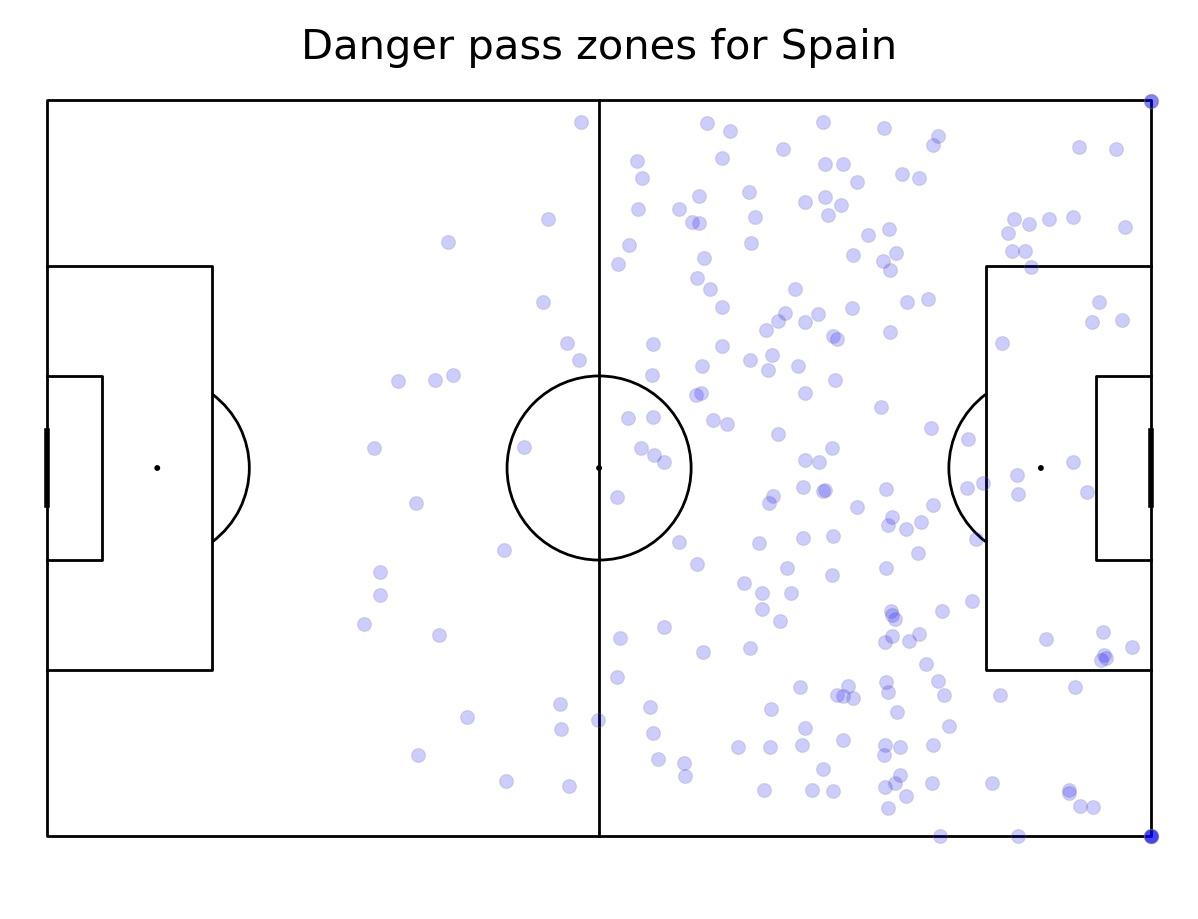

In [10]:
# Accumulate "danger passes" across all of Spain's matches in the tournament.
# A danger pass is defined as any completed pass by Spain that occurred within
# a 15-second window immediately preceding one of Spain's shot attempts.
# This heuristic identifies passes that directly contributed to attacking sequences
# leading to shots — a proxy for pass involvement in chance creation.
danger_passes = pd.DataFrame()

for idx in match_ids:
    # parser.event() returns four DataFrames; [0] is the main event stream for the match.
    df = parser.event(idx)[0]

    # Process each half independently to avoid the half-time boundary causing false matches.
    # A pass at minute 44 should not be linked to a shot at minute 46 (different period).
    for period in [1, 2]:

        # --- Collect all completed passes by Spain in this period ---
        # outcome_name.isnull() selects successful passes (failed passes have a non-null outcome).
        mask_pass = (
            (df.team_name == team) &
            (df.type_name == "Pass") &
            (df.outcome_name.isnull()) &
            (df.period == period)
        )
        passes = df.loc[mask_pass, ["x", "y", "end_x", "end_y", "minute", "second", "player_name"]]

        # --- Collect all Spain shots in this period ---
        mask_shot = (
            (df.team_name == team) &
            (df.type_name == "Shot") &
            (df.period == period)
        )
        shots = df.loc[mask_shot, ["minute", "second"]]

        # Convert minute+second to a single absolute time value in seconds for arithmetic.
        shot_times = shots["minute"] * 60 + shots["second"]

        # Define the start of each shot's 15-second window.
        # If shot_start would go negative (early in the first half), clamp it to
        # the start of the current period: (period - 1) * 45 * 60 seconds.
        shot_window = 15
        shot_start = shot_times - shot_window
        shot_start = shot_start.apply(lambda i: i if i > 0 else (period - 1) * 45)

        pass_times = passes['minute'] * 60 + passes['second']

        # For each pass, check whether its timestamp falls inside any shot window.
        # (shot_start < x) & (x < shot_times) produces a boolean Series per pass;
        # .unique() extracts the distinct boolean values and True in (...) returns True
        # if the pass falls within at least one shot window.
        pass_to_shot = pass_times.apply(
            lambda x: True in ((shot_start < x) & (x < shot_times)).unique()
        )

        danger_passes_period = passes.loc[pass_to_shot]
        danger_passes = pd.concat([danger_passes, danger_passes_period], ignore_index=True)

# --- Scatter plot: raw spatial distribution of danger pass origins ---
# Each marker represents one danger pass origin (x, y) across all matches.
# alpha=0.2 makes markers semi-transparent so spatial density is visible through overlap.
# s=100 sets a uniform marker size — no quality encoding at this stage.
pitch = Pitch(line_color='black')
fig, ax = pitch.grid(
    grid_height=0.9, title_height=0.06, axis=False,
    endnote_height=0.04, title_space=0, endnote_space=0
)
pitch.scatter(
    danger_passes.x, danger_passes.y,
    s=100, color='blue', edgecolors='grey', linewidth=1, alpha=0.2,
    ax=ax["pitch"]
)
fig.suptitle(f'Danger pass zones for {team}', fontsize=30)
plt.show()

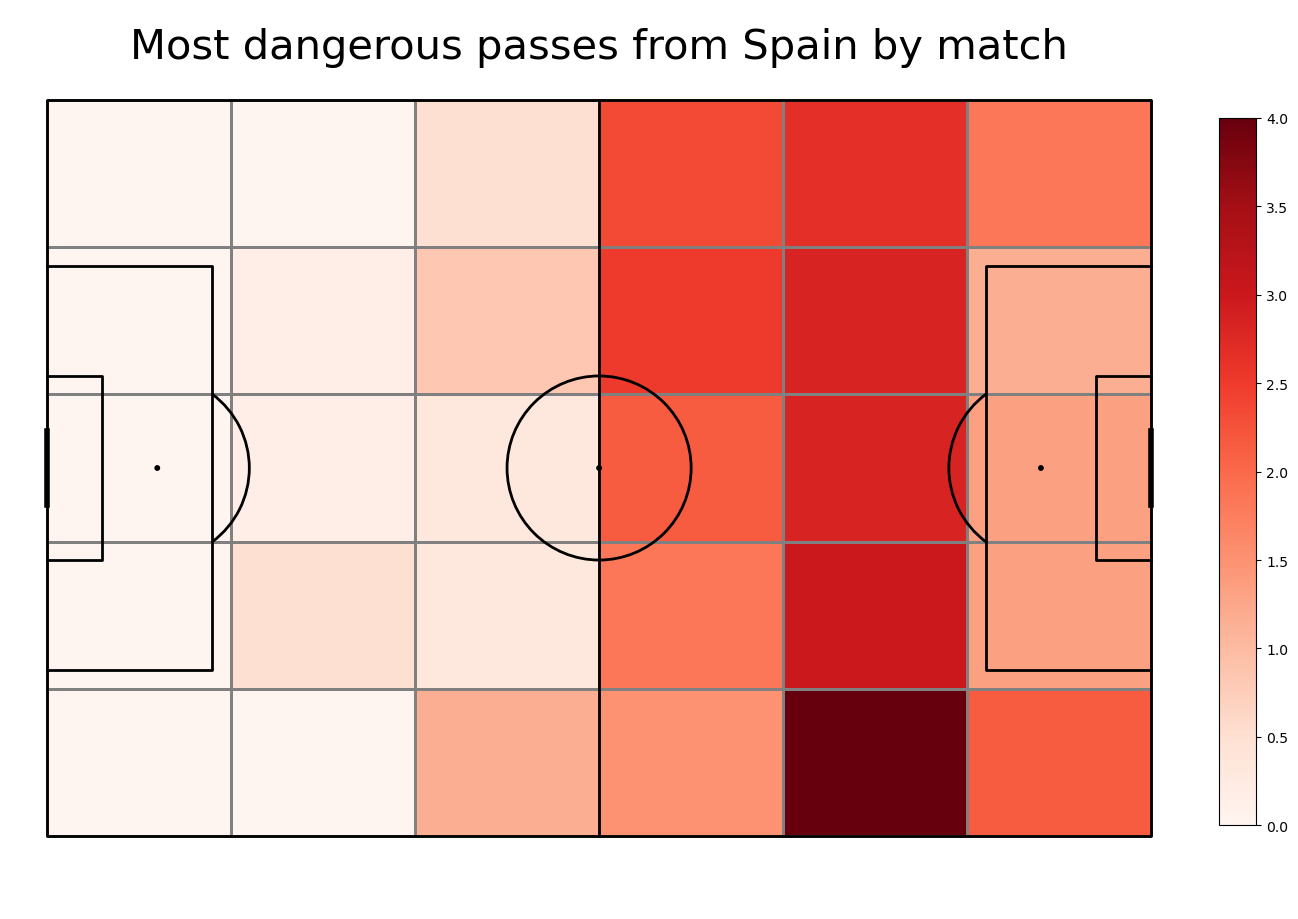

In [11]:
# --- Binned heatmap: normalized danger pass density per match ---
# line_zorder=2 ensures pitch markings are rendered above the heatmap fill.
pitch = Pitch(line_color='black', line_zorder=2)
fig, ax = pitch.grid(
    grid_height=0.9, title_height=0.06, axis=False,
    endnote_height=0.04, title_space=0, endnote_space=0
)

# pitch.bin_statistic() divides the pitch into a grid of rectangular bins and
# computes an aggregate statistic within each cell.
# bins=(6, 5) creates a 6-column x 5-row grid (30 zones total) across the 120x80 pitch.
# statistic='count' tallies the number of danger pass origins falling in each bin.
# normalize=False returns raw counts, which are then manually divided by no_games below.
bin_statistic = pitch.bin_statistic(
    danger_passes.x, danger_passes.y,
    statistic='count', bins=(6, 5), normalize=False
)

# Divide the count matrix by no_games to convert from cumulative totals to a per-match average.
# This normalizes for tournament length, making Spain's 6-match dataset comparable
# to a team that played fewer matches.
bin_statistic["statistic"] = bin_statistic["statistic"] / no_games

# pitch.heatmap() renders the binned statistic as a colored grid on the pitch.
# cmap='Reds' maps low values to light red and high values to dark red,
# making high-density zones immediately visible.
# edgecolor='grey' draws zone boundaries so individual bin outlines are visible.
# The returned pcm (PathCollection/mappable) is needed for the colorbar below.
pcm = pitch.heatmap(bin_statistic, cmap='Reds', edgecolor='grey', ax=ax['pitch'])

# Add a vertical colorbar to the right of the figure to show the count scale.
# fig.add_axes() positions the colorbar axis manually: (left, bottom, width, height)
# in figure-relative coordinates (0–1). Values are tuned to align with the pitch grid.
ax_cbar = fig.add_axes((1, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)

fig.suptitle(f'Most dangerous passes from {team} by match', fontsize=30)
plt.show()

## Summary: Danger Pass Heatmap

### What This Notebook Does

This notebook identifies and visualizes "danger passes" — completed passes by Spain in UEFA Euro 2020 that occurred within a 15-second window before one of Spain's own shot attempts. The analysis runs across all 6 of Spain's matches in the tournament and produces two views: a raw scatter of danger pass origins and a normalized per-match binned heatmap.

### Key Concepts

- **Danger pass definition**: A pass is classified as a danger pass if its timestamp (converted to absolute seconds: `minute * 60 + second`) falls within a `[shot_time - 15s, shot_time]` window for any shot by the same team in the same period. This heuristic captures passes that fed into attacking sequences leading to shots — it is a coarser but computationally cheap alternative to event-chain reconstruction via the `related_events` graph.
- **Period-level processing**: The 15-second window is computed independently per half to prevent the half-time gap from producing false links between a late first-half pass and an early second-half shot. The period start time `(period - 1) * 45` is used as the lower clamp for `shot_start` values that would go negative.
- **`pitch.bin_statistic()`**: Divides the 120x80 pitch into a rectangular grid (`bins=(6, 5)` = 30 zones) and applies an aggregate function (`statistic='count'`) within each zone. The raw count matrix is stored in `bin_statistic["statistic"]` as a 2D numpy array, allowing direct arithmetic normalization before rendering.
- **Per-match normalization**: Dividing by `no_games` converts cumulative totals into per-match averages. This is essential for comparing teams or tournament stages with different numbers of matches — a team that played 7 games would appear artificially more dangerous without this step.
- **`pitch.heatmap()`**: Renders the binned statistic grid as a filled color map on the pitch. `cmap='Reds'` provides an intuitive low-to-high color gradient. The returned `pcm` (Patchwork/QuadMesh) object is passed to `plt.colorbar()` to add a scale reference.
- **Manual colorbar placement**: `fig.add_axes((left, bottom, width, height))` in figure-relative coordinates gives precise control over colorbar positioning, necessary when using `pitch.grid()`'s structured layout which doesn't expose a native colorbar slot.

### Data Available

| Object | Content |
|---|---|
| `danger_passes` | DataFrame of all danger passes across Spain's 6 matches: origin (x, y), destination (end_x, end_y), minute, second, player_name |
| `bin_statistic` | Dict containing the 2D count array (`statistic`), bin edges, and center coordinates — usable directly with `pitch.heatmap()` |
| `no_games` | Integer count of matches (6 for Spain in Euro 2020) used for per-match normalization |

### Ideas to Extract More Value

- **Danger pass destinations**: This notebook maps only the pass *origins* (where the ball came from). Plotting `end_x/end_y` instead reveals which zones Spain was delivering the ball *into* before shots — typically the penalty area corners and the top of the box.
- **Per-player danger pass volume**: Group `danger_passes` by `player_name` and count rows to rank Spain's players by their contribution to pre-shot sequences. This identifies the specific players driving chance creation.
- **Danger pass network overlay**: Combine this dataset with the pass network approach from notebook 4, restricting edges to danger passes only. This produces a "threat network" showing which player pairs were most involved in building up to shots.
- **Window sensitivity analysis**: The 15-second window is arbitrary. Testing 10s, 20s, and 30s windows and comparing the resulting heatmaps can reveal how robust the spatial pattern is and what window best captures genuine chance-creation involvement.
- **Opposition comparison**: Run the same pipeline for Spain's opponents across the same matches. Overlaying or differencing the two heatmaps reveals spatial asymmetries — zones where Spain generated danger that the opposition did not, indicating tactical superiority in specific areas.
- **Finer bin resolution**: `bins=(6, 5)` produces 30 zones and is suitable for 6 matches. With a full league season (38 matches), increasing to `bins=(12, 8)` or `bins=(16, 12)` produces a higher-resolution map without sparsity issues.
- **xG-weighted danger pass heatmap**: Instead of counting danger passes, weight each one by the xG of the shot it preceded. Change `statistic='count'` to a custom function that sums associated xG values per zone. This separates zones that generate many low-quality shots from zones that generate fewer but higher-quality chances.